🧠 Célula 1 - Importar bibliotecas

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

🧠 Célula 2 - Carregar dataset

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 15s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 3s 1us/step


🧠 Célula 3 - Normalizar dados

In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

🧠 CÉLULA 4 — Visualizar imagens

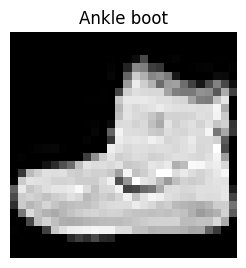

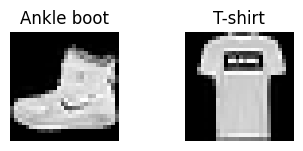

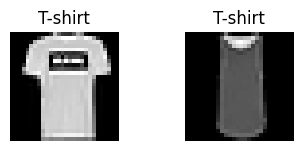

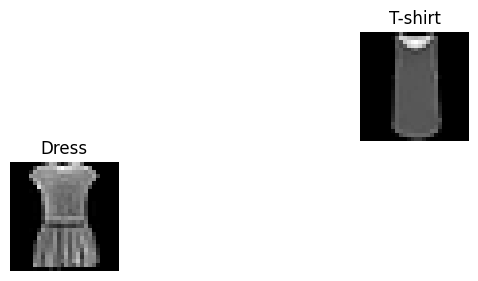

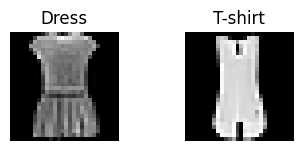

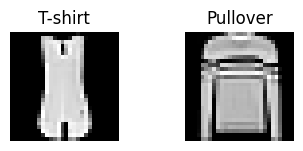

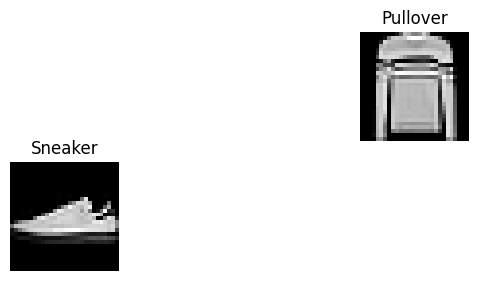

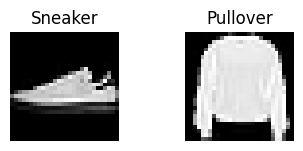

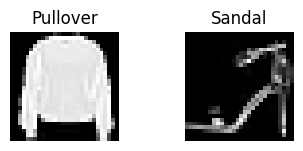

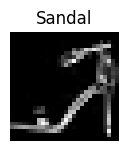

In [4]:
classes = [
"T-shirt",
"Trouser",
"Pullover",
"Dress",
"Coat",
"Sandal",
"Shirt",
"Sneaker",
"Bag",
"Ankle boot"
]

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_train[i], cmap="gray")

    plt.title(classes[y_train[i]])

    plt.axis("off")

    plt.show()
    plt.subplot(3,3,i+1)
    
    plt.imshow(X_train[i], cmap="gray")
    
    plt.title(classes[y_train[i]])
    
    plt.axis("off")
plt.show() 

🚨 PARTE 1 — UNDERFITTING 
🧠 CÉLULA 5 

In [5]:
model_under = keras.Sequential([
  keras.layers.Flatten(input_shape=(28,28)),
  
  keras.layers.Dense(5, activation="relu"),
  
  keras.layers.Dense(10, activation="softmax")
])

c:\Users\Notebook\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


🧠 CÉLULA 6 

In [6]:
model_under.compile(
  optimizer="adam",
  
  loss="sparse_categorical_crossentropy",
  
  metrics=["accuracy"]
)

🧠 CÉLULA 7 

In [7]:
history_under = model_under.fit(
  X_train,
  y_train,
  
  epochs=5,
  
  validation_data=(X_test,y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7081 - loss: 0.8453 - val_accuracy: 0.7835 - val_loss: 0.6251
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8022 - loss: 0.5706 - val_accuracy: 0.8068 - val_loss: 0.5649
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8167 - loss: 0.5296 - val_accuracy: 0.8125 - val_loss: 0.5417
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8253 - loss: 0.5079 - val_accuracy: 0.8143 - val_loss: 0.5296
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8303 - loss: 0.4945 - val_accuracy: 0.8037 - val_loss: 0.5443


🧠 CÉLULA 8 — Gráfico 

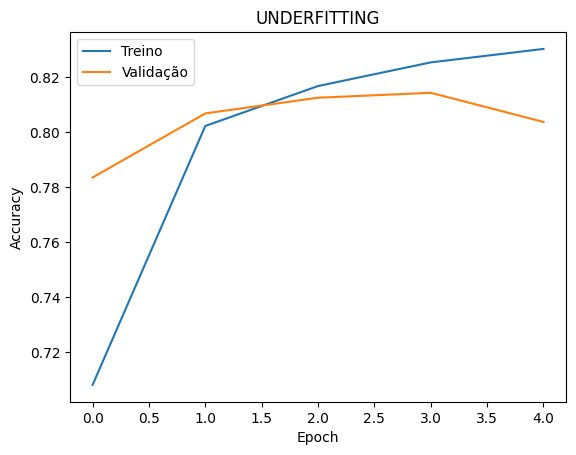

In [8]:
plt.plot(history_under.history['accuracy'], label='Treino')

plt.plot(history_under.history['val_accuracy'], label='Validação')

plt.title("UNDERFITTING")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()


🚨 PARTE 2 — OVERFITTING 
🧠 CÉLULA 9

In [9]:
model_over = keras.Sequential([

  keras.layers.Flatten(input_shape=(28,28)),
  
  keras.layers.Dense(512, activation="relu"),
  
  keras.layers.Dense(512, activation="relu"),
  
  keras.layers.Dense(512, activation="relu"),
  
  keras.layers.Dense(10, activation="softmax")
])

🧠 CÉLULA 10

In [10]:
model_over.compile(
  optimizer="adam",
  
  loss="sparse_categorical_crossentropy",
  
  metrics=["accuracy"]
)

🧠 CÉLULA 11

In [11]:
history_over = model_over.fit(
  X_train,
  y_train,
  
  epochs=20,
  
  validation_data=(X_test,y_test)
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.8250 - loss: 0.4782 - val_accuracy: 0.8387 - val_loss: 0.4354
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8657 - loss: 0.3668 - val_accuracy: 0.8621 - val_loss: 0.3778
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8781 - loss: 0.3299 - val_accuracy: 0.8661 - val_loss: 0.3686
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8862 - loss: 0.3058 - val_accuracy: 0.8778 - val_loss: 0.3330
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8938 - loss: 0.2848 - val_accuracy: 0.8749 - val_loss: 0.3516
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8975 - loss: 0.2729 - val_accuracy: 0.8744 - val_loss: 0.3539
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9026 - loss: 0.2577 - val_accuracy: 0.8781 - val_loss: 0.3605
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9066 -

🧠 CÉLULA 12 — Gráfico

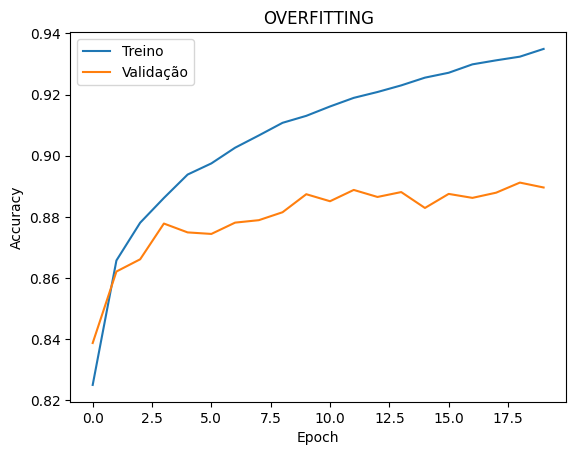

In [12]:
plt.plot(history_over.history['accuracy'], label='Treino')

plt.plot(history_over.history['val_accuracy'], label='Validação')

plt.title("OVERFITTING")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

🚀 PARTE 3 — REGULARIZAÇÃO 
🧠 CÉLULA 13 

In [13]:
model_reg = keras.Sequential([
  keras.layers.Flatten(input_shape=(28,28)),
  
  keras.layers.Dense(512, activation="relu"),
  
  keras.layers.Dropout(0.3),
  
  keras.layers.Dense(512, activation="relu"),
  
  keras.layers.Dropout(0.3),
  
  keras.layers.Dense(10, activation="softmax")
]) 

🧠 CÉLULA 14 

In [15]:
early_stop = keras.callbacks.EarlyStopping(
  monitor='val_loss',
  
  patience=3
)

🧠 CÉLULA 15 

In [ ]:
model_reg.compile(
  optimizer="adam",
  
  loss="sparse_categorical_crossentropy",
  
  metrics=["accuracy"]
)

🧠 CÉLULA 16 

In [18]:
history_reg = model_reg.fit(
  X_train,
  y_train,
  
  epochs=20,
  
  validation_data=(X_test,y_test),
  
  callbacks=[early_stop]
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8904 - loss: 0.2970 - val_accuracy: 0.8833 - val_loss: 0.3432
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8915 - loss: 0.2933 - val_accuracy: 0.8752 - val_loss: 0.3500
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8935 - loss: 0.2871 - val_accuracy: 0.8827 - val_loss: 0.3320


🧠 CÉLULA 17 — Gráfico final 

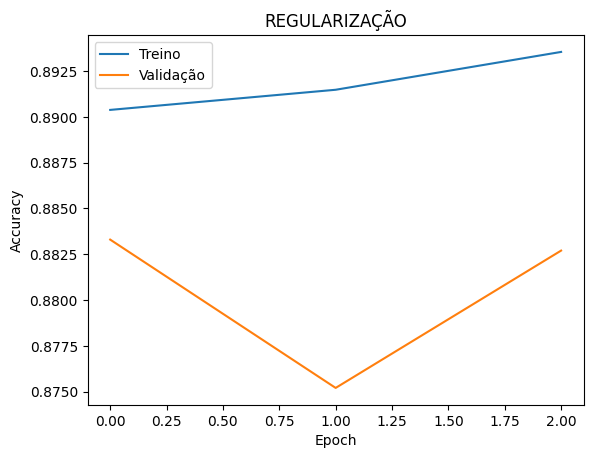

In [19]:
plt.plot(history_reg.history['accuracy'], label='Treino')

plt.plot(history_reg.history['val_accuracy'], label='Validação')

plt.title("REGULARIZAÇÃO")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

🧠 Perguntas e Respostas


"""
1) Qual modelo apresentou underfitting?
Resposta: model_under.
Motivo: arquitetura muito simples (poucos neurônios), com baixo desempenho em treino e validação.

2) Qual modelo apresentou overfitting?
Resposta: model_over.
Motivo: desempenho muito alto no treino e pior na validação, indicando memorização.

3) O Dropout ajudou? Como?
Resposta: Sim.
Como: o Dropout desativa neurônios aleatoriamente no treino, reduz overfitting e melhora a generalização.

4) O EarlyStopping interrompeu o treinamento em qual momento?
Resposta: quando val_loss não melhorou por 3 épocas consecutivas (patience=3).

5) Qual modelo apresentou melhor generalização?
Resposta: model_reg.
Motivo: obteve melhor equilíbrio entre desempenho de treino e validação. """